In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
image_size = 128
batch_size = 32

train_dir = "dataset/train"
val_dir = "dataset/validate"
test_dir = "dataset/test"

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [6]:
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

print("Classes:", train_dataset.classes)

Classes: ['0', '1']


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

/opt/miniconda/envs/eai/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [8]:
class FaceCNN(nn.Module):
    
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),
            nn.Linear(256*8*8,512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512,2)
        )

    def forward(self,x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [9]:
model = FaceCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
def train_epoch(model, loader):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images,labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()*images.size(0)

        _,pred = torch.max(outputs,1)

        correct += (pred==labels).sum().item()

        total += labels.size(0)

    return total_loss/total , correct/total

In [11]:
def evaluate(model, loader):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    y_true=[]
    y_pred=[]

    with torch.no_grad():

        for images,labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs,labels)

            total_loss += loss.item()*images.size(0)

            _,pred = torch.max(outputs,1)

            correct += (pred==labels).sum().item()

            total += labels.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    return total_loss/total , correct/total , y_true , y_pred

In [19]:
epochs = 10

for epoch in range(epochs):

    train_loss , train_acc = train_epoch(model,train_loader)

    val_loss , val_acc , _ , _ = evaluate(model,val_loader)

    print(f"Epoch {epoch+1}/{epochs}")

    print("Train Loss:",train_loss,"Train Acc:",train_acc)

    print("Val Loss:",val_loss,"Val Acc:",val_acc)

Epoch 1/10
Train Loss: 0.45240941287190856 Train Acc: 0.7899109874059581
Val Loss: 0.37089742328717523 Val Acc: 0.8369574204216619
Epoch 2/10
Train Loss: 0.3290242703378613 Train Acc: 0.86047344779122
Val Loss: 0.28257150627478633 Val Acc: 0.8831335262505168
Epoch 3/10
Train Loss: 0.2481122083608191 Train Acc: 0.9005980103067214
Val Loss: 0.21576943253869604 Val Acc: 0.9168664737494833
Epoch 4/10
Train Loss: 0.19474223552146835 Train Acc: 0.9254140601317277
Val Loss: 0.1965703369813204 Val Acc: 0.924596940884663
Epoch 5/10
Train Loss: 0.16124442596503155 Train Acc: 0.9394824592829388
Val Loss: 0.18183786950608136 Val Acc: 0.9314592806945019
Epoch 6/10
Train Loss: 0.13450837638809685 Train Acc: 0.9488384269848706
Val Loss: 0.17003813770104165 Val Acc: 0.9364200082678793
Epoch 7/10
Train Loss: 0.11155035347978387 Train Acc: 0.9583873012373577
Val Loss: 0.17903948303384443 Val Acc: 0.9385283174865647
Epoch 8/10
Train Loss: 0.09512107985589892 Train Acc: 0.9643674043045719
Val Loss: 0.1744

In [29]:
import sys
!{sys.executable} -m pip install grad-cam


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [12]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import cv2
import numpy as np

In [13]:
target_layer = model.features[9]

In [14]:
img_path, label = val_dataset.samples[0]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (128,128))

img_float = img.astype(np.float32) / 255

input_tensor = transform(Image.open(img_path)).unsqueeze(0).to(device)

In [15]:
cam = GradCAM(model=model, target_layers=[target_layer])

grayscale_cam = cam(input_tensor=input_tensor,
                    targets=[ClassifierOutputTarget(label)])

grayscale_cam = grayscale_cam[0]

(-0.5, 127.5, 127.5, -0.5)

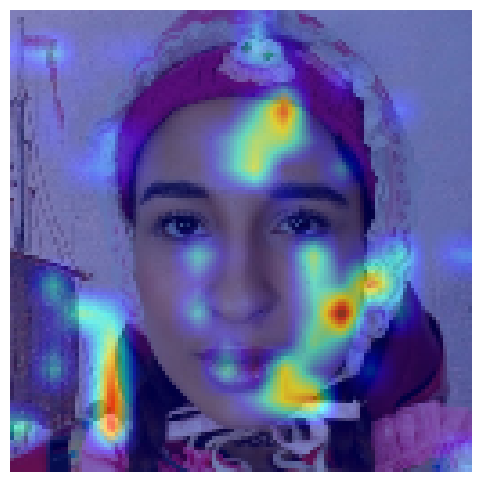

In [16]:
visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

plt.figure(figsize=(6,6))
plt.imshow(visualization)
plt.axis("off")

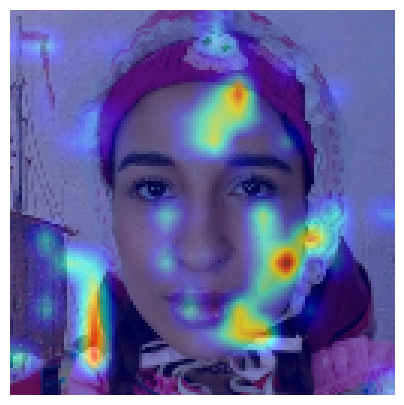

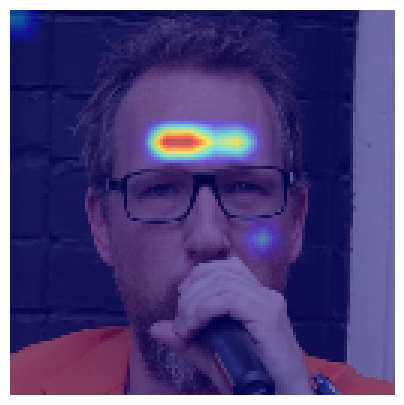

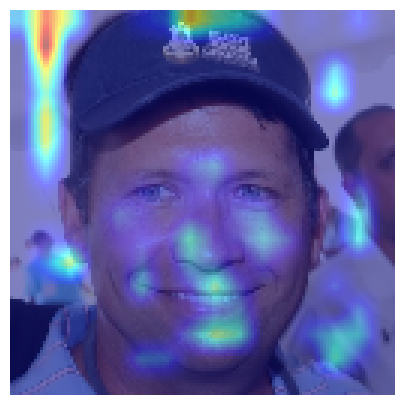

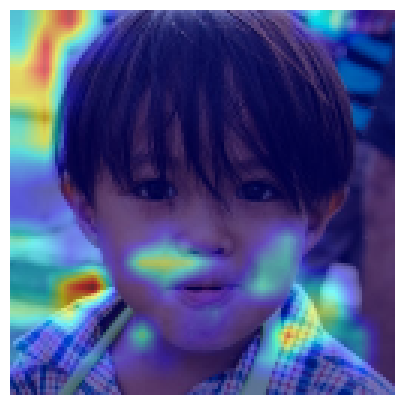

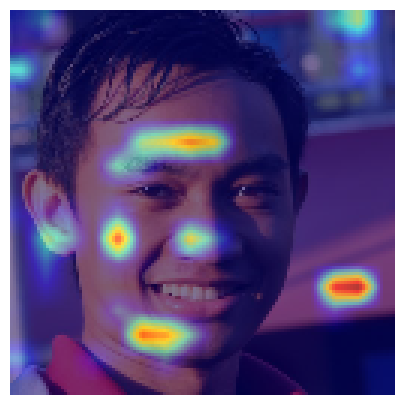

In [17]:
for i in range(5):

    img_path, label = val_dataset.samples[i]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128,128))

    img_float = img.astype(np.float32) / 255

    input_tensor = transform(Image.open(img_path)).unsqueeze(0).to(device)

    cam = GradCAM(model=model, target_layers=[target_layer])

    grayscale_cam = cam(input_tensor=input_tensor,
                        targets=[ClassifierOutputTarget(label)])[0]

    visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(5,5))
    plt.imshow(visualization)
    plt.axis("off")